In [2]:
from DatasetLoading import RepairDatasetLoader

import os

import numpy as np
import torch
import matplotlib.pyplot as plt

from NerfRepresentationUtils import plot_colored_voxels
from NerfRepresentationUtils import plot_opacity_tensor
import torch.nn.functional as F


from tqdm import tqdm

from torchvision.utils import save_image

from EvaluationUtils import show_point_cloud
from EvaluationUtils import PointTransformerV3
from EvaluationUtils import PointNet2

import torch_pointcloud as tp

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

/home/enego/Documents/masters/RayRepresentationTesting/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
dataset_loader = RepairDatasetLoader(batch_size=2, dataset_type="RandomRotationPointCloudsDataloader",
                                         representation_folder_name="pointclouds2_5k", num_workers=2)

In [4]:
test_dataloader = dataset_loader.test_dataloader()

In [5]:
batch = next(iter(test_dataloader))
points, normals, colors, rotation = batch

<Axes3D: title={'center': 'Point Cloud'}>

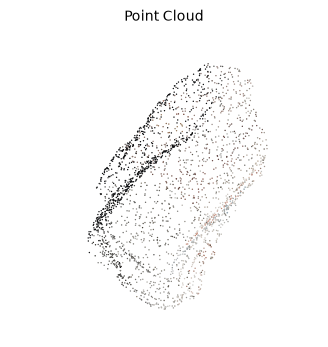

In [6]:
show_point_cloud(points[0], colors[0]/255.0, title="Point Cloud", size=1)

In [11]:
ptv3 = PointTransformerV3().to(device)

/home/enego/Documents/masters/RayRepresentationTesting/.venv/lib/python3.12/site-packages/torch_pointcloud/models/_registry.py:462: UserWarning: Ignoring checkpoint keys from 'hf://torch-pointcloud/ptv3-base.s3dis-area5.pointcept/resolve/main/model.safetensors' absent from the model: head.bias, head.weight.
  load_state_dict(model, read_state_dict(local_path), source=weights["url"])


W0915 13:16:08.768000 886950 .venv/lib/python3.12/site-packages/torch/fx/_symbolic_trace.py:53] is_fx_tracing will return true for both fx.symbolic_trace and torch.export. Please use is_fx_tracing_symbolic_tracing() for specifically fx.symbolic_trace or torch.compiler.is_compiling() for specifically torch.export/compile.


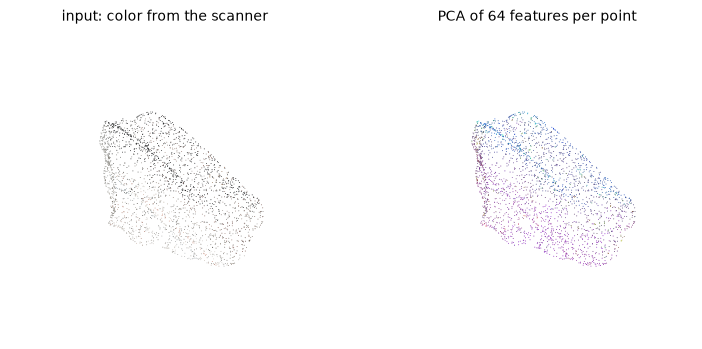

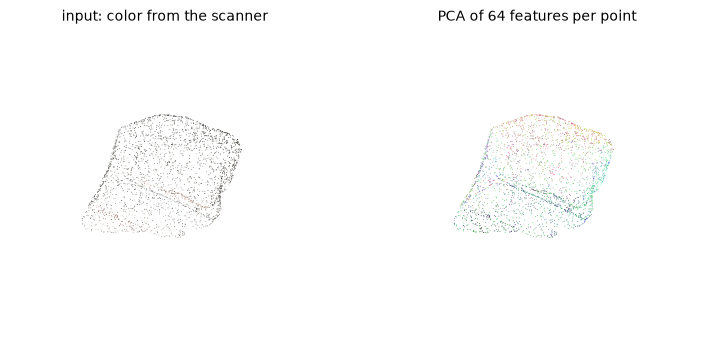

In [12]:
features = ptv3([x.to(device) for x in batch], visualise=True)

In [8]:
pointnet2 = PointNet2().to(device)

/home/enego/Documents/masters/RayRepresentationTesting/.venv/lib/python3.12/site-packages/torch_pointcloud/models/_registry.py:462: UserWarning: Ignoring checkpoint keys from 'hf://torch-pointcloud/pointnet2.s3dis-area5.openpoints/resolve/main/model.safetensors' absent from the model: head.lins.0.bias, head.lins.0.weight, head.lins.1.bias, head.lins.1.weight, head.norms.0.module.bias, head.norms.0.module.num_batches_tracked, head.norms.0.module.running_mean, head.norms.0.module.running_var, head.norms.0.module.weight.
  load_state_dict(model, read_state_dict(local_path), source=weights["url"])


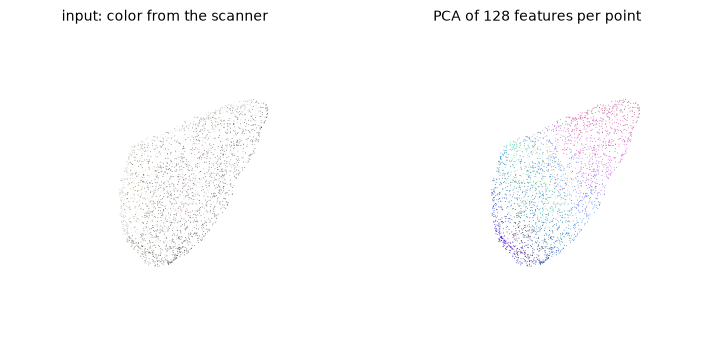

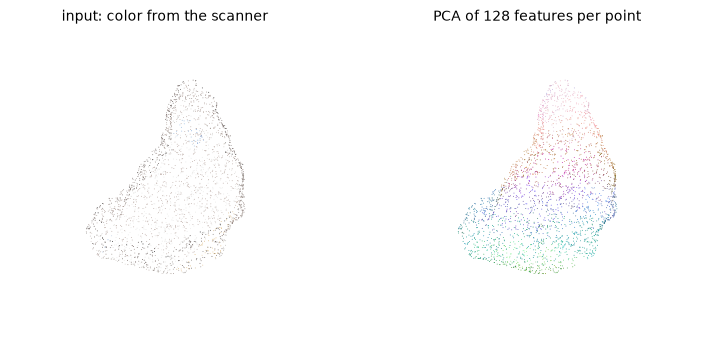

tensor([[[0.4721, 0.0000, 0.0000,  ..., 0.0000, 0.4371, 0.0000],
         [0.2089, 0.0000, 0.1315,  ..., 0.0000, 0.2658, 0.2706],
         [0.2618, 0.4575, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         ...,
         [0.7242, 0.2258, 0.8802,  ..., 0.0000, 0.2740, 1.6473],
         [0.1867, 0.0000, 0.0000,  ..., 0.0000, 0.5728, 0.0830],
         [0.5199, 0.0000, 0.0000,  ..., 0.0000, 0.0851, 0.0000]],

        [[0.2485, 0.0074, 0.1839,  ..., 0.0000, 0.5004, 0.5065],
         [0.1897, 0.0000, 0.4583,  ..., 0.0000, 0.0000, 1.1019],
         [0.1833, 0.5429, 0.1450,  ..., 0.0000, 0.1603, 1.7224],
         ...,
         [0.3327, 0.0000, 0.1974,  ..., 0.0000, 0.4045, 0.9132],
         [0.0000, 0.0000, 0.1142,  ..., 0.0000, 0.0000, 0.8200],
         [0.1010, 0.2203, 0.2521,  ..., 0.0000, 0.0000, 1.3073]]],
       device='cuda:0')

In [9]:
pointnet2([x.to(device) for x in batch], visualise=True)

In [7]:
from torch_pointcloud.models import list_models

In [8]:
list_models(task="segmentation", pretrained=True)

['concerto-large-lp.scannet20.pointcept',
 'dgcnn.s3dis-area1.an-tao',
 'dgcnn.s3dis-area2.an-tao',
 'dgcnn.s3dis-area3.an-tao',
 'dgcnn.s3dis-area4.an-tao',
 'dgcnn.s3dis-area5.an-tao',
 'dgcnn.s3dis-area6.an-tao',
 'dgcnn.scannet20.an-tao',
 'dgcnn.shapenetpart.an-tao',
 'kpfcnn-base-deform.s3dis.hugues-thomas',
 'kpfcnn-base-sm-deform.s3dis.hugues-thomas',
 'kpfcnn-base-sm.s3dis.hugues-thomas',
 'kpfcnn-base.s3dis.hugues-thomas',
 'octformer-base.scannet20.octree-nn',
 'octformer-base.scannet200.octree-nn',
 'point-m2ae-base.shapenetpart.renrui-zhang',
 'point-mae-base.shapenetpart.yatian-pang',
 'pointnet2.s3dis-area1.openpoints',
 'pointnet2.s3dis-area2.openpoints',
 'pointnet2.s3dis-area3.openpoints',
 'pointnet2.s3dis-area4.openpoints',
 'pointnet2.s3dis-area5.openpoints',
 'pointnet2.s3dis-area5.xu-yan',
 'pointnet2.s3dis-area6.openpoints',
 'pointnext-base.s3dis-area1.openpoints',
 'pointnext-base.s3dis-area2.openpoints',
 'pointnext-base.s3dis-area3.openpoints',
 'pointnext-b

In [9]:
model, info = tp.create_model(
    "kpfcnn-base.s3dis.hugues-thomas",
    task="segmentation",
    pretrained=True,
    num_classes=0,
    return_info=True
)
model = model.eval().to(device)

100%|██████████| 93.2M/93.2M [00:03<00:00, 26.7MB/s]
/home/enego/Documents/masters/RayRepresentationTesting/.venv/lib/python3.12/site-packages/torch_pointcloud/models/_registry.py:462: UserWarning: Ignoring checkpoint keys from 'hf://torch-pointcloud/kpfcnn-base.s3dis.hugues-thomas/resolve/main/model.safetensors' absent from the model: head.0.0.bias, head.0.0.weight, head.1.bias, head.1.weight.
  load_state_dict(model, read_state_dict(local_path), source=weights["url"])


In [13]:
packaged_data = ptv3.package_pointcloud(batch)

In [14]:
info

{'name': 'kpfcnn-base.s3dis.hugues-thomas',
 'transform': Compose(
   CopyItems(keys=('pos', 'segment'), allow_missing_keys=True, names=('origin_pos', 'origin_segment')),
   Voxelize(keys=('color', 'segment'), allow_missing_keys=False, pos_key='pos', pos_reduce='mean', size=0.03, reduce=('mean', 'first'), method='pyg', dst_inverse_key='inverse', dst_pos_grid_key=None, random_sample=False, generator=None),
   Scale(keys=('color',), allow_missing_keys=False, scale=(0.00392156862745098,)),
   AxisMinOffset(keys=('pos',), allow_missing_keys=False, dst_keys=('height',), axis=(2,), quantile=None),
   OnesLike(keys=('height',), allow_missing_keys=False, dst_keys=('ones',), memory_format=(None,), dtype=(None,), layout=(None,), device=(None,), pin_memory=(False,), requires_grad=(False,)),
   Cat(keys=('ones', 'color', 'height'), allow_missing_keys=False, dst_key='x', dim=-1),
   RenameItems(keys=('segment',), allow_missing_keys=False, names=('label',)),
   KeepItems(keys=('x', 'pos', 'label', '

In [15]:
info["transform"](packaged_data).keys()

dict_keys(['x', 'pos', 'label', 'origin_pos', 'origin_segment', 'inverse'])

In [16]:
info["transform"](packaged_data)["pos"].shape

torch.Size([4532, 3])

In [17]:
info["transform"](packaged_data)["index"]

KeyError: 'index'

In [18]:
import inspect

In [19]:
print(inspect.signature(model.forward))

(x: Optional[torch.Tensor], pos: torch.Tensor, batch: torch.Tensor) -> torch.Tensor


In [28]:
transformed_pointcloud_data["segment"].shape

torch.Size([4963])

In [38]:
#transformed_pointcloud_data["x"] = transformed_pointcloud_data["x"][transformed_pointcloud_data["segment"] > 0]
#transformed_pointcloud_data["pos_grid"] = transformed_pointcloud_data["pos_grid"][transformed_pointcloud_data["segment"] > 0]
#transformed_pointcloud_data["inverse"] = transformed_pointcloud_data["inverse"][transformed_pointcloud_data["batch"] > 0]
#transformed_pointcloud_data["origin_pos"] = transformed_pointcloud_data["origin_pos"][transformed_pointcloud_data["batch"] > 0]
#transformed_pointcloud_data["segment"] = transformed_pointcloud_data["segment"][transformed_pointcloud_data["segment"] > 0]

In [45]:
with torch.inference_mode():
    features = model(
        transformed_pointcloud_data["x"].to(device),
        transformed_pointcloud_data["pos_grid"].to(device),
        batch = transformed_pointcloud_data["segment"].to(device)
    )

In [46]:
def pca_color(feat: torch.Tensor) -> torch.Tensor:
    """Map a per-point feature (N, C) to RGB in [0, 1] through its top principal components."""
    _, _, components = torch.pca_lowrank(feat, center=True, q=6, niter=5)
    projected = feat @ components
    projected = projected[:, :3] * 0.6 + projected[:, 3:6] * 0.4
    low, high = projected.min(0, keepdim=True).values, projected.max(0, keepdim=True).values
    return ((projected - low) / (high - low).clamp_min(1e-6)).clamp(0, 1)

In [51]:
features.shape

torch.Size([4963, 64])

tensor(1)

In [53]:
rgb = torch.zeros_like(transformed_pointcloud_data["pos"])
for i in range(torch.max(transformed_pointcloud_data["segment"]) + 1):
    mask = transformed_pointcloud_data["segment"] == i
    rgb[mask] = pca_color(features[mask].cpu())

In [54]:
def show_clouds(clouds, titles, point_size=1.0, columns=None, height=4.4):
    """Draw one cloud per panel, colored by its own `color`: RGB rows in [0, 1], or one color for the panel."""
    columns = columns or len(clouds)
    rows = -(-len(clouds) // columns)
    _, axes = plt.subplots(rows, columns, figsize=(4.4 * columns, height * rows), subplot_kw={"projection": "3d"})
    for ax, cloud, title in zip(np.ravel(axes), clouds, titles):
        pos = np.asarray(cloud["pos"])
        ax.scatter(*pos.T, c=cloud["color"], s=point_size, linewidths=0, depthshade=False)
        ax.set_box_aspect(np.ptp(pos, axis=0))
        ax.set_title(title, fontsize=10)
        ax.set_axis_off()
    plt.show()

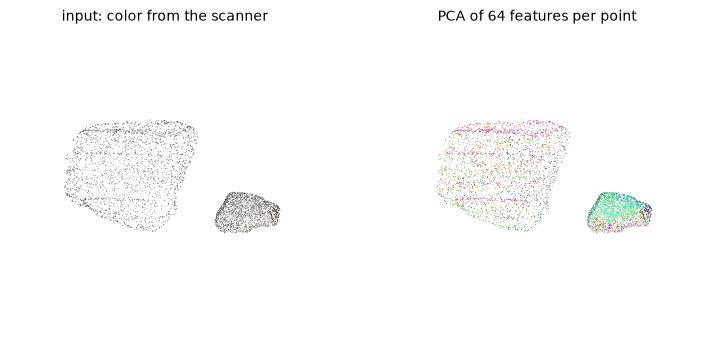

In [55]:
show_clouds(
    [{"pos": pointcloud_data["pos"], "color": pointcloud_data["color"] / 255}, {"pos": transformed_pointcloud_data["origin_pos"], "color": rgb[transformed_pointcloud_data["inverse"]]}],
    ["input: color from the scanner", f"PCA of {features.shape[1]:,} features per point"],
    point_size=0.4,
)

W0913 03:29:35.999000 1101588 .venv/lib/python3.12/site-packages/torch/fx/_symbolic_trace.py:53] is_fx_tracing will return true for both fx.symbolic_trace and torch.export. Please use is_fx_tracing_symbolic_tracing() for specifically fx.symbolic_trace or torch.compiler.is_compiling() for specifically torch.export/compile.


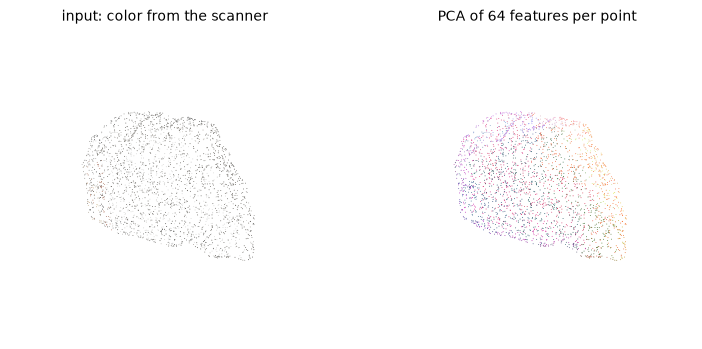

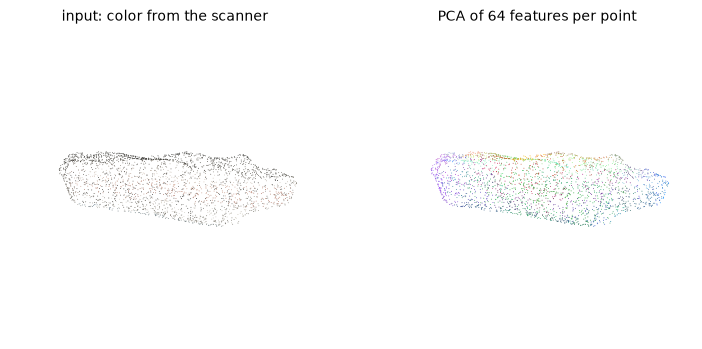

In [18]:
features = ptv3([x.to(device) for x in batch], visualise=True)

In [19]:
features.shape

torch.Size([2, 2500, 64])

In [77]:
type(batch[0])

torch.Tensor

In [78]:
batch[0].shape

torch.Size([2, 2500, 3])

In [75]:
pointcloud_data.keys()

dict_keys(['pos', 'normal', 'color', 'category', 'batch', 'segment'])

In [84]:
pointcloud_data2.keys()


dict_keys(['pos', 'normal', 'color', 'category', 'batch', 'segment'])

In [86]:
pointcloud_data2["pos"].shape

torch.Size([7500])

In [89]:
type(batch2)

list

In [94]:
batch[0].shape

torch.Size([2, 2500, 3])

In [99]:
pointcloud_data2["pos"].shape

torch.Size([5000, 3])

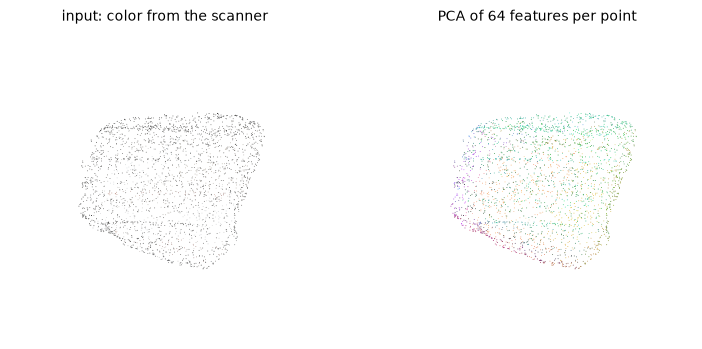

In [100]:
batch2 = [x[:1] for x in batch]
pointcloud_data2 = package_pointcloud(batch2)
transformed_pointcloud_data2 = info["transform"](pointcloud_data2)
with torch.inference_mode():
    features2 = model(
        transformed_pointcloud_data2["x"].to(device),
        transformed_pointcloud_data2["pos_grid"].to(device),
        batch = transformed_pointcloud_data2["segment"].to(device)
    )
rgb2 = pca_color(features2).cpu()
show_clouds(
    [{"pos": pointcloud_data2["pos"], "color": pointcloud_data2["color"] / 255}, {"pos": transformed_pointcloud_data2["origin_pos"], "color": rgb2[transformed_pointcloud_data2["inverse"]]}],
    ["input: color from the scanner", f"PCA of {features2.shape[1]:,} features per point"],
    point_size=0.4,
)

In [67]:
rgb2[transformed_pointcloud_data["inverse"][mask_2]].shape

IndexError: index 4293 is out of bounds for dimension 0 with size 2494

In [68]:
rgb2.shape

torch.Size([2494, 3])

In [69]:
max(transformed_pointcloud_data["inverse"][mask_2])

tensor(4962)

In [ ]:
print("per cloud:", tuple(per_cloud.shape), "| head:", type(model_clf.head).__name__, "| C:", model_clf.num_features)

In [24]:
pointcloud_data["pos"].shape

torch.Size([2500, 3])

In [32]:
pred.shape

torch.Size([76, 32, 3])

In [33]:
type(model)

torch_pointcloud.models.point_mae.PointMAEMaskedAutoEncoder

In [34]:
type(model.encoder)

AttributeError: 'PointMAEMaskedAutoEncoder' object has no attribute 'encoder'

In [35]:
print(type(model))
print(model)
print(model.__dict__.keys())

<class 'torch_pointcloud.models.point_mae.PointMAEMaskedAutoEncoder'>
PointMAEMaskedAutoEncoder(
  (MAE_encoder): MaskTransformer(
    (encoder): PointPatchEmbed(
      (local_mlp): MLP(3, 128, 256)
      (global_mlp): MLP(512, 512, 384)
    )
    (pos_embed): MLP(3, 128, 384)
    (blocks): TransformerEncoder(
      (blocks): ModuleList(
        (0): TransformerBlock(
          (norm1): LayerNorm((384,), eps=1e-05, elementwise_affine=True)
          (attn): Attention(
            (qkv): Linear(in_features=384, out_features=1152, bias=False)
            (attn_drop): Dropout(p=0.0, inplace=False)
            (proj): Linear(in_features=384, out_features=384, bias=True)
            (proj_drop): Dropout(p=0.0, inplace=False)
          )
          (drop_path): DropPath(drop_prob=0.000)
          (norm2): LayerNorm((384,), eps=1e-05, elementwise_affine=True)
          (mlp): MLP(384, 1536, 384)
        )
        (1): TransformerBlock(
          (norm1): LayerNorm((384,), eps=1e-05, elementwis

In [80]:
print(model.forward_features)

<bound method PointTransformerV3Segmentation.forward_features of PointTransformerV3Segmentation(
  (encoder): PointTransformerV3Encoder(
    (stem): SubMConv3dBlock(
      (stem): SubMConv3d(6, 32, kernel_size=[5, 5, 5], stride=[1, 1, 1], padding=[1, 1, 1], dilation=[1, 1, 1], output_padding=[0, 0, 0], bias=False, algo=ConvAlgo.Native)
      (norm): BatchNorm(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (act): GELU(approximate='none')
    )
    (blocks): ModuleList(
      (0): PointTransformerV3EncoderBlock(
        (blocks): ModuleList(
          (0): PointTransformerV3Block(
            (cpe_conv): SubMConv3d(32, 32, kernel_size=[3, 3, 3], stride=[1, 1, 1], padding=[0, 0, 0], dilation=[1, 1, 1], output_padding=[0, 0, 0], algo=ConvAlgo.MaskImplicitGemm)
            (cpe_proj): Linear(in_features=32, out_features=32, bias=True)
            (cpe_norm): LayerNorm(32, affine=True, mode=node)
            (norm1): LayerNorm(32, affine=True, mode=node)
          